In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [1]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Getting started.pdf', 'EXO_엑소_Universe_MV.mp3', "y2mate.com - BAEKHYUN 백현 'Candy' (Sweet Ver.) @BAEKHYUN THE STAGE_8Ylv5B6SI4w_480p.mp4", 'y2mate.com - [BTS - 21st Century Girls] Comeback Stage _ M COUNTDOWN 161013 EP.496_z0J26eCipr8_480p.mp4', 'y2mate.com - MV Drama Hymn of death (Bada - Praise of Death  OST) 🎼💔😭_hvg076vNVjQ_480p.mp4', 'y2mate.com - 방탄소년단 - FAKE LOVE (BTS - FAKE LOVE) │BTS COMEBACK SHOW 180524 180524_6LB4JWRnyrM_480p (1).mp4', 'y2mate.com - [BTS - Go Go] Comeback Stage _ M COUNTDOWN 170928 EP.543_TEl6KgcfSA8_480p.mp4', 'y2mate.com - 방탄소년단 - FAKE LOVE (BTS - FAKE LOVE) │BTS COMEBACK SHOW 180524 180524_6LB4JWRnyrM_480p.mp4', 'act(5).pdf', 'Hadi Inshallah.mp4', 'Kiralik Ask.m4a', 'Haberin Yok (1).mp4', 'Gümüshane Kizlari (1).m4a', 'Haberin Yok.mp4', 'Sinsirella.m4a', 'Bagdat.mp4', 'Gümüshane Kizlari.m4a', 'Kardesim Benim.m4a', 'CamScanner 09-23-2020 16.22.45.pdf', 'y2mate.com - BTS (방탄소년단) - Airplane pt.2 [Music Bank COMEBACK  2018

In [3]:
DATASET_PATH = "/content/drive/MyDrive/FaceRecognition/dataset"

TEST_PATH = "/content/drive/MyDrive/FaceRecognition/test_images"

In [4]:
import os

print(os.listdir(DATASET_PATH))

['Mariam', 'Ahmed', 'Abeya']


In [5]:
print(os.listdir(DATASET_PATH + "/Ahmed"))

['Ahmed 2.jpeg', 'Ahmed 1.jpeg']


(np.float64(-0.5), np.float64(711.5), np.float64(662.5), np.float64(-0.5))

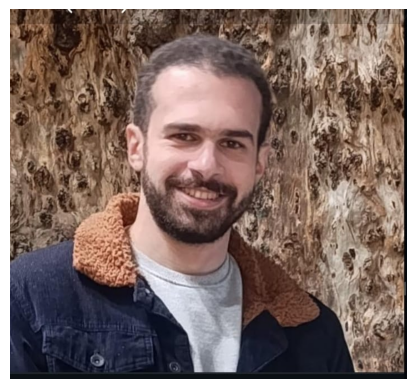

In [7]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(DATASET_PATH + "/Ahmed/Ahmed 1.jpeg")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")

In [8]:
!pip install tensorflow opencv-python matplotlib scikit-learn

In [9]:
import os
import cv2
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, Model

In [11]:
IMG_SIZE = 100

images = []
labels = []

persons = sorted(os.listdir(DATASET_PATH))

for person in persons:

    folder = os.path.join(DATASET_PATH, person)

    for img_name in os.listdir(folder):

        img = cv2.imread(os.path.join(folder,img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))  #resize each images to 100 x 100 pixels because images have different sizes so it has to be unified in dimensions
        img = img.astype("float32")/255.0

        images.append(img)   #stores image
        labels.append(person) #lables person's name for each image

images = np.array(images)
labels = np.array(labels)

print(images.shape) #image characteristics, pixels , RGB
print(labels.shape) #6 labels for 6 images
print(labels)  # the labels help defining each person and decide which are simmilar

(6, 100, 100, 3)
(6,)
['Abeya' 'Abeya' 'Ahmed' 'Ahmed' 'Mariam' 'Mariam']


In [12]:
pairs = []
pair_labels = [] #stores if the pairs are 0 or 1

for i in range(len(images)):  #loop on each image being the "anchor"

    anchor = images[i]    #the image itself
    anchor_label = labels[i]  #its label "Ahmed"

    # Positive
    pos_indices = np.where(labels==anchor_label)[0]   #searches between other image and return the one where its label is the same as the current anchor "image" we are using in the loop
    pos_indices = pos_indices[pos_indices != i] #remove the anchor itself "i" so it doesnt compare with itself

    if len(pos_indices)>0:

        pos = images[random.choice(pos_indices)]  #chooses positive images

        pairs.append([anchor,pos])  #stores them [Ahmed 1, Ahmed 2]
        pair_labels.append(1)  #give them label 1

    # Negative

    neg_indices = np.where(labels!=anchor_label)[0]  #if label not equal the anchor label
    neg = images[random.choice(neg_indices)] #pick one randomly of the negative results

    pairs.append([anchor,neg]) #save the pair
    pair_labels.append(0)

pairs = np.array(pairs) #converts the Python list into a NumPy array.
pair_labels = np.array(pair_labels)

print(pairs.shape) #12 training pairs, Each training example contains 2 images,image height and width,RGB

(12, 2, 100, 100, 3)


In [13]:
x_train,x_test,y_train,y_test = train_test_split(
    pairs,
    pair_labels,
    test_size=0.2,
    random_state=42
)

In [15]:
def embedding_network():  #converts the image into list of numbers is called an embedding or feature vector so siamese can compare them.

    inputs = layers.Input((100,100,3))

    x = layers.Conv2D(32,3,activation='relu')(inputs) #conv.layers learns patterns like eyes, nose.. with 32 diff.feature detectors.each filter is 3x3 pixels
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64,3,activation='relu')(x) #This layer combines small features into more complex ones like learning a whole face
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128,3,activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)

    x = layers.Dense(256,activation='relu')(x)

    outputs = layers.Dense(128)(x)

    return Model(inputs,outputs)

embedding = embedding_network()

In [16]:
def euclidean_distance(vectors): #calc distance to check if same person =small distance, different persons = large distance

    x,y = vectors

    sum_square = tf.reduce_sum(tf.square(x-y),axis=1,keepdims=True)

    return tf.sqrt(tf.maximum(sum_square,tf.keras.backend.epsilon()))

In [19]:
inputA = layers.Input((100,100,3))  #Building siamese network with 2 images entering the embedding using same CNN with shared weights.
inputB = layers.Input((100,100,3))

embA = embedding(inputA)
embB = embedding(inputB)

distance = layers.Lambda(euclidean_distance)([embA,embB])

output = layers.Dense(1,activation='sigmoid')(distance)

siamese = Model([inputA,inputB],output)

In [20]:
siamese.compile(

    optimizer="adam",  #Updates the network weights to reduce error during training.

    loss="binary_crossentropy",   #Measures how wrong the predicted similarity (0–1) is compared with the true label (0 or 1).

    metrics=["accuracy"]

)

In [21]:
history = siamese.fit(   #train the neural netwrok

    [x_train[:,0],x_train[:,1]], #takes 1st image from every pair, 2nd image from every pair then train on it

    y_train,

    validation_data=([x_test[:,0],x_test[:,1]],y_test),  #images never used before, so after every epoch it asks "How well does the model perform on images it has never seen before?"

    epochs=20,

    batch_size=8

)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 483ms/step - accuracy: 0.5556 - loss: 0.7056 - val_accuracy: 0.3333 - val_loss: 0.7967
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 181ms/step - accuracy: 0.5556 - loss: 0.6868 - val_accuracy: 0.3333 - val_loss: 0.6936
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.5556 - loss: 0.6370 - val_accuracy: 0.3333 - val_loss: 0.7081
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.5556 - loss: 0.6362 - val_accuracy: 0.3333 - val_loss: 0.7282
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step - accuracy: 0.5556 - loss: 0.6132 - val_accuracy: 0.3333 - val_loss: 0.7292
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step - accuracy: 0.5556 - loss: 0.5642 - val_accuracy: 0.3333 - val_loss: 0.7063
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.5556 - loss: 0.5370 - val_accuracy: 0.3333 - val_loss: 0.6850
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - accuracy: 0.5556 - loss: 0.5047 - val_accuracy: 0.3333 - val_loss:

In [22]:
siamese.save("FaceRecognitionModel.keras")

In [23]:
import os
import cv2
import numpy as np

TEST_PATH = "/content/drive/MyDrive/FaceRecognition/test_images"

# Threshold to decide if the face is known
THRESHOLD = 0.5

for test_file in os.listdir(TEST_PATH):

    test_path = os.path.join(TEST_PATH, test_file)

    test_img = cv2.imread(test_path)
    test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
    test_img = cv2.resize(test_img, (100,100))
    test_img = test_img.astype("float32") / 255.0

    best_score = -1
    best_person = None

    print(f"\nTesting {test_file}")

    for person in os.listdir(DATASET_PATH):

        person_folder = os.path.join(DATASET_PATH, person)

        if not os.path.isdir(person_folder):
            continue

        # Use the first image of each person as the reference
        reference_image = os.listdir(person_folder)[0]
        reference_path = os.path.join(person_folder, reference_image)

        ref_img = cv2.imread(reference_path)
        ref_img = cv2.cvtColor(ref_img, cv2.COLOR_BGR2RGB)
        ref_img = cv2.resize(ref_img, (100,100))
        ref_img = ref_img.astype("float32") / 255.0

        score = siamese.predict([
            np.expand_dims(test_img, axis=0),
            np.expand_dims(ref_img, axis=0)
        ], verbose=0)[0][0]

        print(f"{person}: {score:.4f}")

        if score > best_score:
            best_score = score
            best_person = person

    if best_score >= THRESHOLD:
        print(f"\nPrediction: {best_person}")
        print(f"Similarity Score: {best_score:.4f}")
    else:
        print("\nPrediction: 0 (Unknown Person)")
        print(f"Highest Score: {best_score:.4f}")

    print("-"*50)


Testing unknown1.jpeg
Mariam: 0.1277
Ahmed: 0.1257
Abeya: 0.1528

Prediction: 0 (Unknown Person)
Highest Score: 0.1528
--------------------------------------------------

Testing unknown2.jpeg
Mariam: 0.1700
Ahmed: 0.1275
Abeya: 0.1275

Prediction: 0 (Unknown Person)
Highest Score: 0.1700
--------------------------------------------------

Testing unknown3.jpeg
Mariam: 0.0412
Ahmed: 0.5048
Abeya: 0.0274

Prediction: Ahmed
Similarity Score: 0.5048
--------------------------------------------------


In [24]:
import cv2
import numpy as np

#Comparing with a new image and an old image from dataset
image1_path = "/content/drive/MyDrive/FaceRecognition/dataset/Abeya/Abeya 1.jpeg"

image2_path = "/content/drive/MyDrive/FaceRecognition/test_images/unknown1.jpeg"

# --------------------------------------


def preprocess(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (100,100))
    img = img.astype("float32") / 255.0
    return img


img1 = preprocess(image1_path)
img2 = preprocess(image2_path)

prediction = siamese.predict([
    np.expand_dims(img1, axis=0),
    np.expand_dims(img2, axis=0)
], verbose=0)[0][0]

print("Similarity Score:", round(float(prediction),4))

THRESHOLD = 0.5

if prediction >= THRESHOLD:
    print("Prediction: SAME PERSON (1)")
else:
    print("Prediction: DIFFERENT PERSON (0)")

Similarity Score: 0.1528
Prediction: DIFFERENT PERSON (0)
